Training Images: (60000, 28, 28)
Testing Images: (10000, 28, 28)


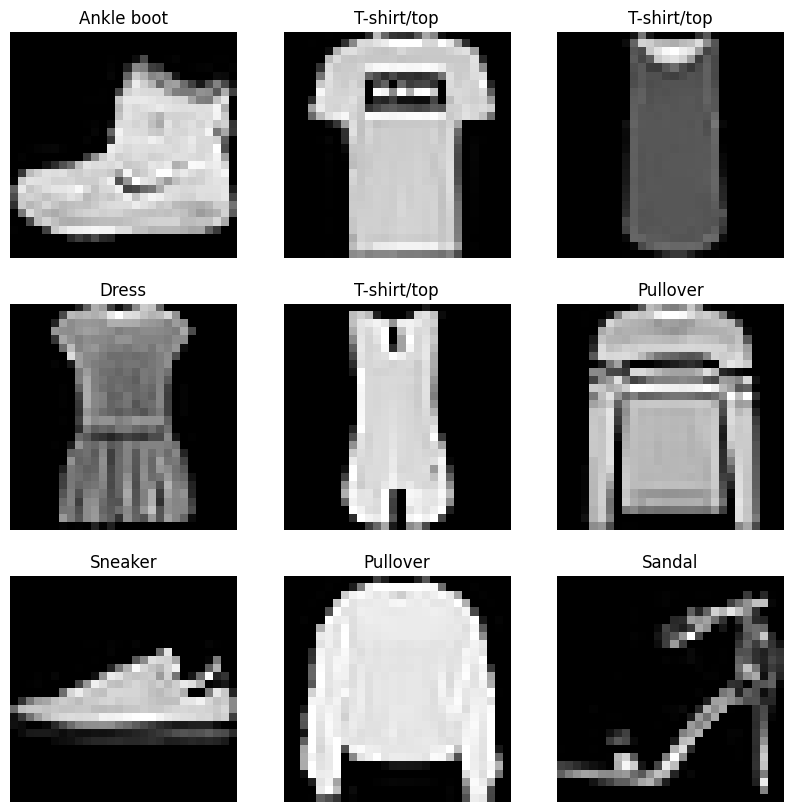

C:\Users\Sadiya\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8191 - loss: 0.5109 - val_accuracy: 0.8536 - val_loss: 0.4139
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8623 - loss: 0.3770 - val_accuracy: 0.8618 - val_loss: 0.3911
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8740 - loss: 0.3408 - val_accuracy: 0.8721 - val_loss: 0.3522
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8834 - loss: 0.3171 - val_accuracy: 0.8630 - val_loss: 0.3706
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8898 - loss: 0.2963 - val_accuracy: 0.8772 - val_loss: 0.3368
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8945 - loss: 0.2835 - val_accuracy: 0.8806 - val_loss: 0.3299
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8995 - loss: 0.2712 - val_accuracy: 0.8863 - val_loss: 0.3267
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9017 - loss: 0

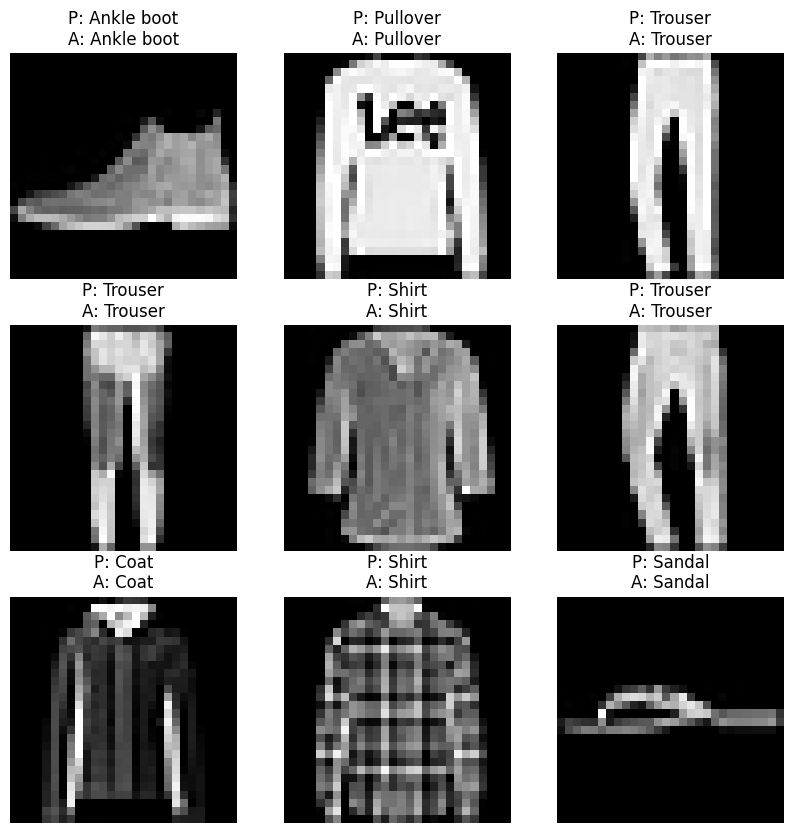

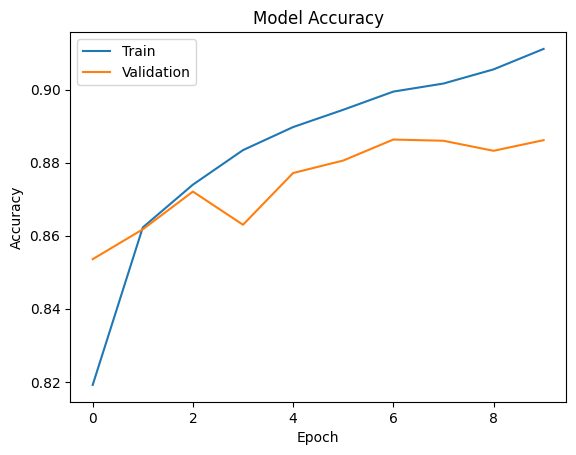

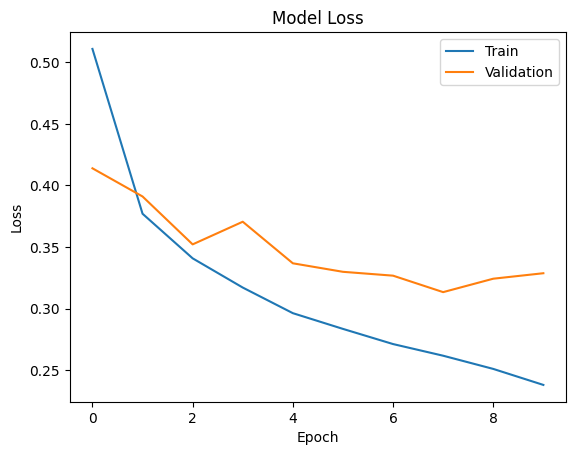

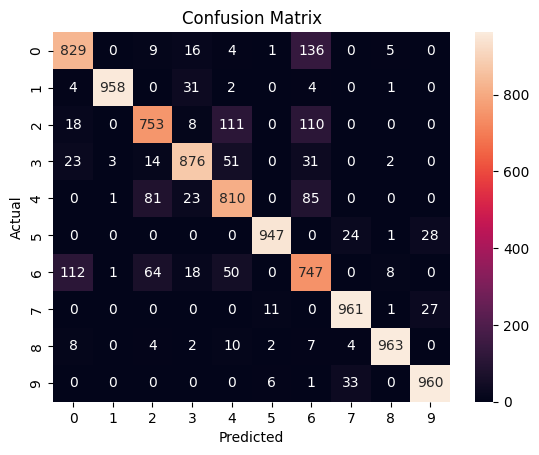

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

fashion_mnist = keras.datasets.fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Training Images:", x_train.shape)
print("Testing Images:", x_test.shape)

x_train = x_train / 255.0
x_test = x_test / 255.0

class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.show()

model = keras.Sequential([

    # Flatten 28x28 image into 1D vector
    layers.Flatten(input_shape=(28,28)),

    # Hidden layer 1
    layers.Dense(128, activation='relu'),

    # Hidden layer 2
    layers.Dense(64, activation='relu'),

    # Output layer
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

loss, accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy:", accuracy)

predictions = model.predict(x_test)

predicted_classes = np.argmax(predictions, axis=1)

print("Predicted Class:", class_names[predicted_classes[0]])
print("Actual Class:", class_names[y_test[0]])

plt.figure(figsize=(10,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(x_test[i], cmap='gray')

    predicted_label = class_names[predicted_classes[i]]
    actual_label = class_names[y_test[i]]

    plt.title(f"P: {predicted_label}\nA: {actual_label}")

    plt.axis('off')

plt.show()

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])

plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(['Train', 'Validation'])

plt.show()

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, predicted_classes)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 8us/step 
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 157s 6us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 33s 8us/step
Training Images: (60000, 28, 28)
Testing Images: (10000, 28, 28)


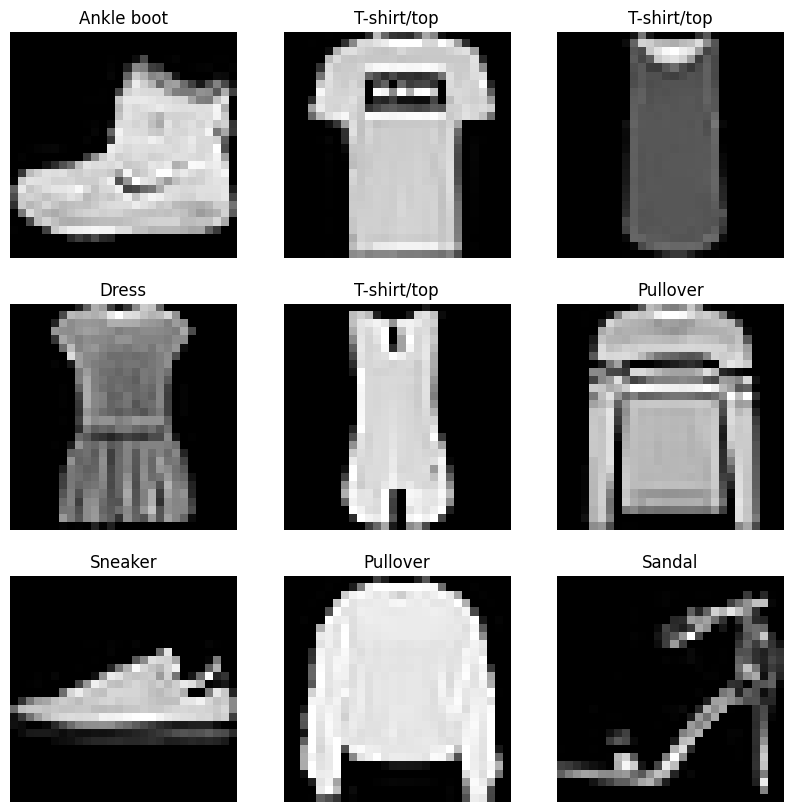

C:\Users\Sadiya\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.8181 - loss: 0.5103 - val_accuracy: 0.8484 - val_loss: 0.4171
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8617 - loss: 0.3808 - val_accuracy: 0.8194 - val_loss: 0.4741
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.8744 - loss: 0.3428 - val_accuracy: 0.8727 - val_loss: 0.3553
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8825 - loss: 0.3177 - val_accuracy: 0.8752 - val_loss: 0.3482
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8894 - loss: 0.3004 - val_accuracy: 0.8813 - val_loss: 0.3333
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.8939 - loss: 0.2837 - val_accuracy: 0.8647 - val_loss: 0.3799
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8984 - loss: 0.2716 - val_accuracy: 0.8823 - val_loss: 0.3263
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9030 - loss: 0

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8811 - loss: 0.3484
Test Accuracy: 0.8810999989509583


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Predicted Class: Ankle boot
Actual Class: Ankle boot


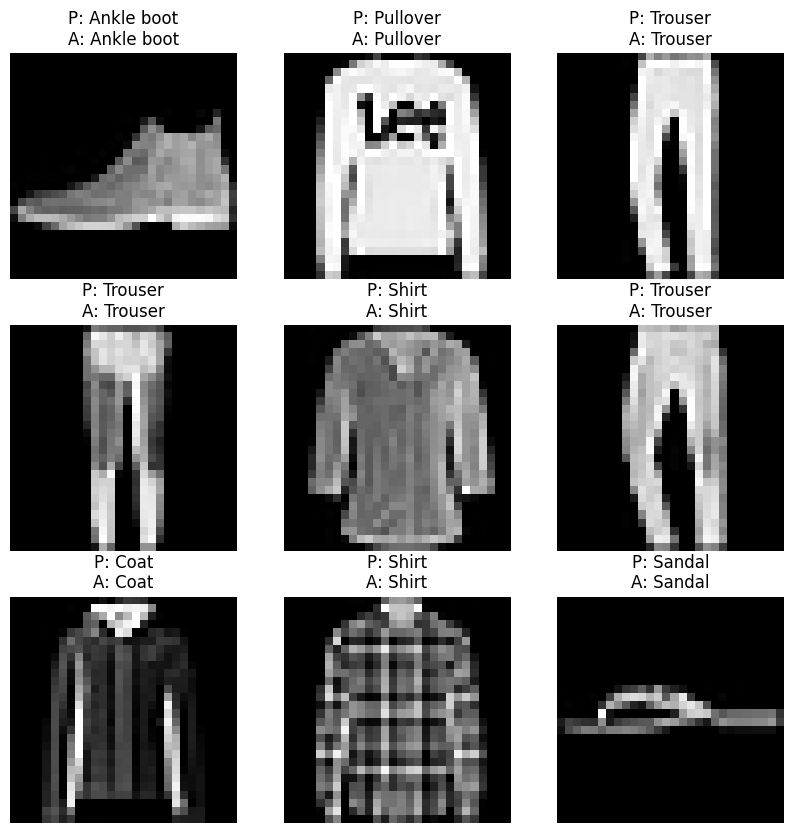

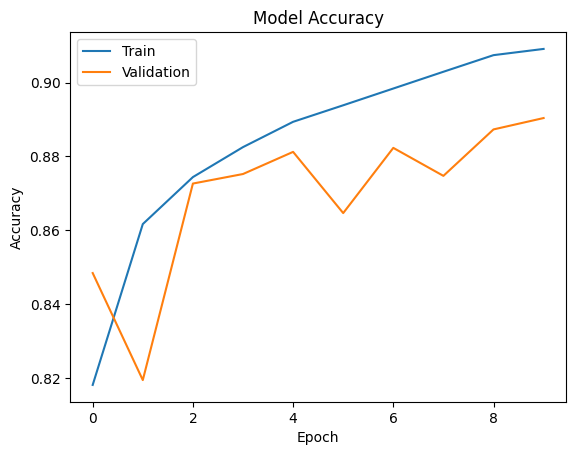

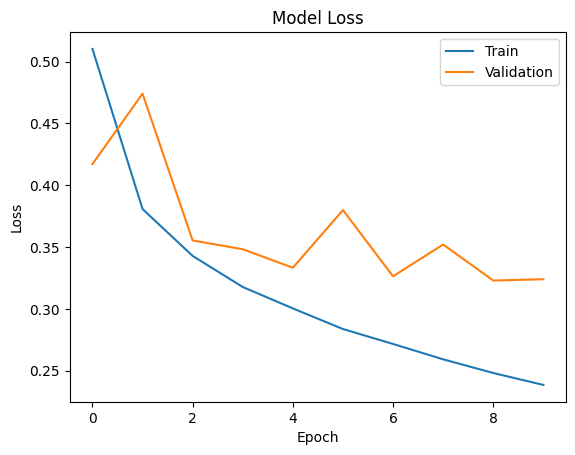

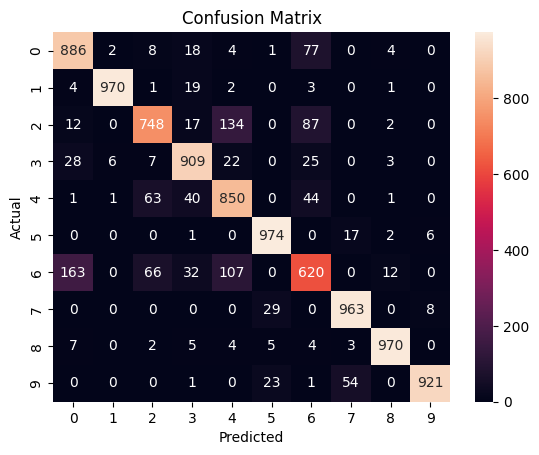

C:\Users\Sadiya\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 19ms/step - accuracy: 0.8518 - loss: 0.4213
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.8979 - loss: 0.2841
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.9120 - loss: 0.2428
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.9216 - loss: 0.2142
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9299 - loss: 0.1916
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9100 - loss: 0.2499
Accuracy: 0.9100000262260437


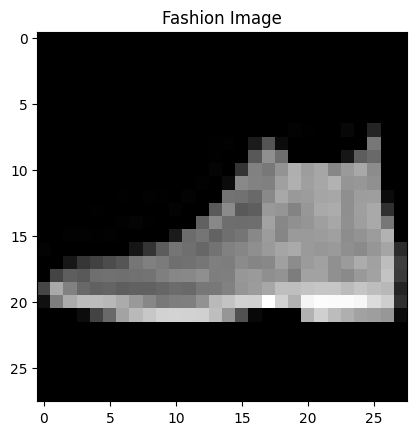

In [15]:
# Import Libraries
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense
import matplotlib.pyplot as plt

# Load Dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize Data
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape Data for CNN
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

# Build CNN Model
model = Sequential()

# Convolution Layer
model.add(Conv2D(32,
                 (3,3),
                 activation='relu',
                 input_shape=(28,28,1)))

# Pooling Layer
model.add(MaxPooling2D((2,2)))

# Flatten Layer
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(64, activation='relu'))

# Output Layer
model.add(Dense(10, activation='softmax'))

# Compile Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train Model
model.fit(X_train,
          y_train,
          epochs=5,
          batch_size=32)

# Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test)

print("Accuracy:", accuracy)

# Show Sample Image
plt.imshow(X_test[0].reshape(28,28), cmap='gray')
plt.title("Fashion Image")
plt.show()